# PPR pilot validation

This notebook validates the five-region Sea Around Us pilot. It is a **pilot prioritization**, not a global estimate. Raw catch includes landings and discards, reported and unreported, for the latest year shared by every pilot archive.

Only the approved Pauly-Christensen trophic-chain calculation is used:

\[
SPPR = 10^{TL-1}
\]

\[
PPR = Catch_{tonnes} \times SPPR
\]

The paper's separate wet-weight-to-carbon divisor of 9 is intentionally omitted, so PPR is reported in tonnes of primary-production equivalent, not grams of carbon.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'output' / 'tables').exists():
    ROOT = ROOT.parent
TABLES = ROOT / 'output' / 'tables'
metadata = json.loads((TABLES / 'run_metadata.json').read_text())
print(f"Pilot year: {metadata['year']} | TE: {metadata['transfer_efficiency']} | Unit: {metadata['ppr_unit']}")

Pilot year: 2019 | TE: 0.1 | Unit: tonnes_primary_production_equivalent


## Regional prioritization and catch totals

,rank_pilot_ppr,unit_id,region_name,region_type,year,total_catch_tonnes,catch_tl_coverage_fraction,ppr_species,fraction_pilot_ppr
0,1,LME_013,Humboldt Current,LME,2019,7.390381e+06,1.0,2.612053e+09,0.315122
1,2,LME_022,North Sea,LME,2019,2.717261e+06,1.0,1.700185e+09,0.205113
2,3,LME_038,Indonesian Sea,LME,2019,2.883542e+06,1.0,1.678212e+09,0.202462
3,4,HS_071,"Pacific, Western Central",High Seas,2019,5.718178e+05,1.0,1.482147e+09,0.178808
4,5,LME_001,East Bering Sea,LME,2019,1.301000e+06,1.0,8.164359e+08,0.098496


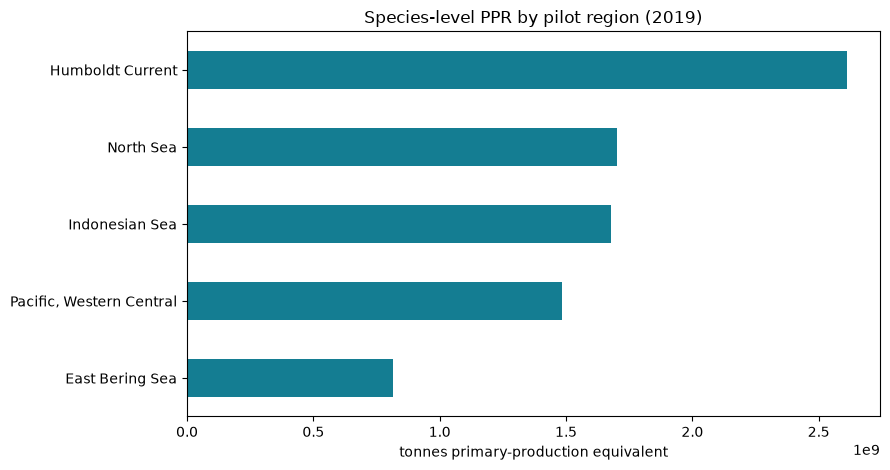

In [2]:
summary = pd.read_csv(TABLES / 'pilot_summary.csv')
display(summary[['rank_pilot_ppr', 'unit_id', 'region_name', 'region_type', 'year',
                 'total_catch_tonnes', 'catch_tl_coverage_fraction', 'ppr_species',
                 'fraction_pilot_ppr']])

ax = summary.sort_values('ppr_species').plot.barh(
    x='region_name', y='ppr_species', legend=False, color='#147D92', figsize=(9, 4.8))
ax.set_title('Species-level PPR by pilot region (2019)')
ax.set_xlabel('tonnes primary-production equivalent')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Catch and aggregation reconciliation

In [3]:
validation = pd.read_csv(TABLES / 'validation.csv')
key_checks = ['catch_reconciled', 'commercial_ppr_reconciled', 'functional_ppr_reconciled',
              'commercial_jensen_violations', 'functional_jensen_violations']
display(validation[validation['check'].isin(key_checks)].pivot(index='unit_id', columns='check', values='value'))

boolean_checks = validation[validation['check'].isin(
    ['catch_reconciled', 'commercial_ppr_reconciled', 'functional_ppr_reconciled'])]
assert boolean_checks['value'].astype(str).str.lower().isin(['true', '1', '1.0']).all()
violation_checks = validation[validation['check'].str.endswith('jensen_violations')]
assert pd.to_numeric(violation_checks['value']).eq(0).all()

check,catch_reconciled,commercial_jensen_violations,commercial_ppr_reconciled,functional_jensen_violations,functional_ppr_reconciled
unit_id,,,,,
HS_071,True,0,True,0,True
LME_001,True,0,True,0,True
LME_013,True,0,True,0,True
LME_022,True,0,True,0,True
LME_038,True,0,True,0,True


## Trophic-level matching coverage

,unit_id,match_method,tl_source,match_confidence,taxa_count,catch_tonnes,catch_fraction
0,HS_071,exact_2020_supplement,2020 supplement MeanTL,high,14,5.496781e+05,0.961282
1,HS_071,exact_sea_around_us,Sea Around Us exploited organisms,high,9,2.213971e+04,0.038718
2,LME_001,exact_sea_around_us,Sea Around Us exploited organisms,high,38,8.573548e+05,0.658997
3,LME_001,exact_2020_supplement,2020 supplement MeanTL,high,35,4.436450e+05,0.341003
4,LME_013,exact_2020_supplement,2020 supplement MeanTL,high,79,6.493517e+06,0.878644
5,LME_013,exact_sea_around_us,Sea Around Us exploited organisms,high,105,8.968639e+05,0.121356
6,LME_022,exact_2020_supplement,2020 supplement MeanTL,high,164,2.360936e+06,0.868866
7,LME_022,exact_sea_around_us,Sea Around Us exploited organisms,high,148,3.563242e+05,0.131134
8,LME_038,exact_sea_around_us,Sea Around Us exploited organisms,high,90,1.944119e+06,0.674212
9,LME_038,exact_2020_supplement,2020 supplement MeanTL,high,52,9.394233e+05,0.325788


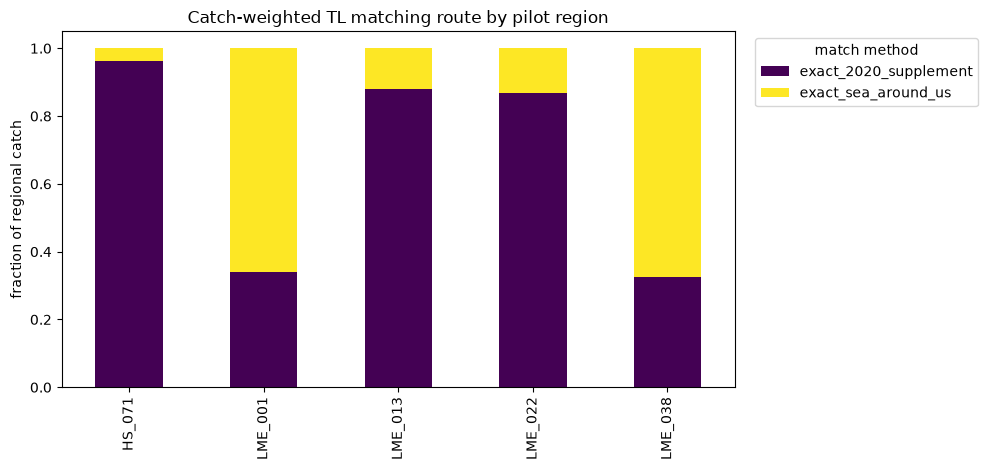

In [4]:
coverage = pd.read_csv(TABLES / 'tl_coverage.csv')
display(coverage[['unit_id', 'match_method', 'tl_source', 'match_confidence',
                  'taxa_count', 'catch_tonnes', 'catch_fraction']])

coverage_pivot = coverage.pivot_table(index='unit_id', columns='match_method',
                                      values='catch_fraction', aggfunc='sum', fill_value=0)
coverage_pivot.plot.bar(stacked=True, figsize=(10, 4.8), colormap='viridis')
plt.title('Catch-weighted TL matching route by pilot region')
plt.ylabel('fraction of regional catch')
plt.xlabel('')
plt.legend(title='match method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Correct aggregation versus intentional Jensen-error aggregation

For both commercial and functional groups, the correct method sums species PPR first. The comparison method deliberately averages TL by catch before exponentiating. Because the exponential is convex, the correct estimate is expected to be greater than or equal to the Jensen-error estimate, apart from floating-point noise.

,unit_id,region_name,classification,ppr_correct,ppr_jensen,underestimate_fraction
0,HS_071,"Pacific, Western Central",commercial,1.482147e+09,1.476698e+09,0.003677
1,HS_071,"Pacific, Western Central",functional,1.482147e+09,1.474269e+09,0.005315
2,LME_001,East Bering Sea,commercial,8.164359e+08,6.515449e+08,0.201964
3,LME_001,East Bering Sea,functional,8.164359e+08,6.896003e+08,0.155353
4,LME_013,Humboldt Current,commercial,2.612053e+09,2.058671e+09,0.211857
5,LME_013,Humboldt Current,functional,2.612053e+09,2.239918e+09,0.142468
6,LME_022,North Sea,commercial,1.700185e+09,1.461272e+09,0.140522
7,LME_022,North Sea,functional,1.700185e+09,1.529129e+09,0.100610
8,LME_038,Indonesian Sea,commercial,1.678212e+09,1.110963e+09,0.338008
9,LME_038,Indonesian Sea,functional,1.678212e+09,1.252315e+09,0.253780


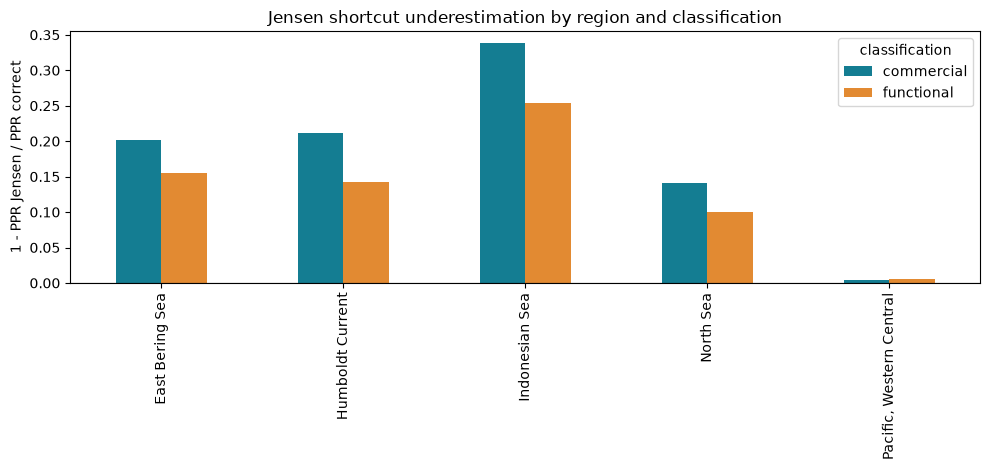

In [5]:
jensen = pd.read_csv(TABLES / 'jensen_comparison.csv')
regional_bias = (jensen.groupby(['unit_id', 'region_name', 'classification'], as_index=False)
                 .agg(ppr_correct=('ppr_correct', 'sum'), ppr_jensen=('ppr_jensen', 'sum')))
regional_bias['underestimate_fraction'] = 1 - regional_bias['ppr_jensen'] / regional_bias['ppr_correct']
display(regional_bias)

pivot = regional_bias.pivot(index='region_name', columns='classification', values='underestimate_fraction')
pivot.plot.bar(figsize=(10, 4.8), color=['#147D92', '#E28A32'])
plt.title('Jensen shortcut underestimation by region and classification')
plt.ylabel('1 - PPR Jensen / PPR correct')
plt.xlabel('')
plt.axhline(0, color='#333333', linewidth=0.8)
plt.tight_layout()
plt.show()

## Final validation gate

In [6]:
assert summary['year'].nunique() == 1
assert summary['catch_tl_coverage_fraction'].between(0, 1).all()
assert (summary['ppr_species'] - summary['ppr_commercial_correct']).abs().max() < 1e-5
assert (summary['ppr_species'] - summary['ppr_functional_correct']).abs().max() < 1e-5
assert summary['rank_pilot_ppr'].tolist() == list(range(1, len(summary) + 1))
print('All pilot validation gates passed.')

All pilot validation gates passed.


## Sources and interpretation

- Sea Around Us catch and spatial data: https://www.seaaroundus.org/data/
- Sea Around Us tools/download guide: https://www.seaaroundus.org/tools-guide/
- Pauly, D. & Christensen, V. (1995), *Primary production required to sustain global fisheries*, Nature 374:255-257.
- Luong et al. (2020) supplementary workbook is used only for `MeanTL`; its alternative SPPR estimates are not used.

The ranking compares the five selected pilot regions only. It must not be interpreted as a global ranking until the same frozen workflow is run over every Sea Around Us LME and High Seas unit.